# `06-workflow.ipynb`

In [2]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

llm = init_chat_model('gpt-4.1-mini')

## Prompt Chaining

- 매우 잘 정리된 업무 순서가 있을 경우 사용
- 이전 노드에서 처리한 내용을 `state`에 담아 다음 노드로 전송


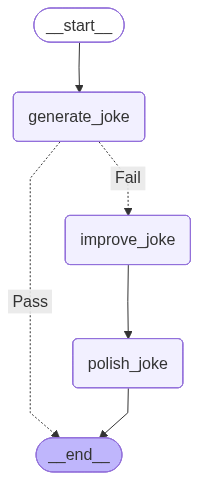

{'topic': '졸림',
 'joke': '졸릴 때 하는 농담 하나 갈게요!\n\n“왜 졸린 사람은 언제나 좋은 수면 약이 될까요?  \n자기 전에 꼭 ‘꿈’을 꾼답니다!”'}

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
# 그림 보는 용
from IPython.display import Image, display

# Graph State
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# Nodes 
def generate_joke(state: State):
    msg = llm.invoke(f'주제 {state['topic']}에 관련된 짧은 농담 생성')
    return {'joke': msg.content}


def improve_joke(state: State):
    msg = llm.invoke(f'말장난을 추가해서 아래 농담을 더 재밌게 만들어보자.\n {state['joke']}')
    return {'improved_joke':msg.content}


def polish_joke(state: State):
    msg = llm.invoke(f'아래 농담을 쩔게 뒤틀어 보자\n {state['improved_joke']}')
    return {'final_joke':msg.content}

# Router
def check_puchline(state: State):
    # ? 나 ! 없으면, improve하고, 있으면 그대로 진행
    if '?' in state['joke'] or '!' in state['joke']:
        return 'Pass'
    else:
        return 'Fail'
    

workflow= StateGraph(State)
workflow.add_node('generate_joke',generate_joke)  # workflow.add_node(generate_joke) 
workflow.add_node('improve_joke',improve_joke)
workflow.add_node('polish_joke',polish_joke)

workflow.add_edge(START, 'generate_joke')
workflow.add_conditional_edges('generate_joke', check_puchline, {'Pass': END,'Fail': 'improve_joke'} )
workflow.add_edge('improve_joke','polish_joke')
workflow.add_edge('polish_joke',END)
                               
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


graph.invoke({'topic': '졸림'})

## Parallelization (병렬화) (비동기)
- 여러 node(llm)이 동시에 작업을 진행
- 뭐가 먼저 끝날지 알 수 없음
- 하위 task를 동시에 진행시켜서 속도 up
- 같은 task를 여러번 동시에 돌려서 신뢰성 확보 

In [6]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    output: str

# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'Write a joke about {state['topic']}')
    return {'joke':msg.content}

def generate_story(state: State):
    msg = llm.invoke(f'Write a story about {state['topic']}')
    return {'story':msg.content}

def generate_poem(state: State):
    msg = llm.invoke(f'Write a pem about {state['topic']}')
    return {'poem':msg.content}

def aggregate(state:State):
    output= f""" 농담, 이야기, 시
                Joke : {state['joke']}
                Story: {state['story']}
                Poem:{state['poem']}
            """
    return {'output':output}

workflow= StateGraph(State)
workflow.add_node(generate_joke)  # workflow.add_node(generate_joke) 
workflow.add_node(generate_story)
workflow.add_node(generate_poem)
workflow.add_node(aggregate)

workflow.add_edge(START, 'generate_joke')
workflow.add_edge(START, 'generate_story')
workflow.add_edge(START, 'generate_poem')
workflow.add_edge('generate_joke', 'aggregate')
workflow.add_edge('generate_story', 'aggregate')
workflow.add_edge('generate_poem', 'aggregate')
workflow.add_edge('aggregate',END)
                               
graph = workflow.compile()
graph

graph.invoke({'topic': '배고픔'})

{'topic': '배고픔',
 'joke': '배고플 때 왜 시계랑 친구가 될 수 없을까요?  \n시간이 갈수록 배가 더 고파지니까요! 😄⏰🍽️',
 'story': '옛날 옛적, 작은 마을에 ‘배고픔’이라는 이름을 가진 소년이 살고 있었습니다. 배고픔은 항상 마음속에 깊은 갈증과 공허함을 느꼈습니다. 그는 배가 고파서만 그런 것이 아니라, 세상에 대한 호기심과 사랑, 그리고 자신의 존재에 대한 갈망 때문에 늘 허기진 상태였습니다.\n\n어느 날, 배고픔은 마을을 떠나 세상을 탐험하기로 결심했습니다. 그는 자신을 채워줄 무언가를 찾기 위해 길을 나섰습니다. 산을 넘고 강을 건너면서 다양한 사람들을 만났고, 그들의 이야기와 따뜻한 마음을 배웠습니다.\n\n하지만 아무리 맛있는 음식을 먹고, 좋은 친구들과 함께해도 배고픔은 여전히 마음속 허기를 느꼈습니다. 그러던 중, 배고픔은 작은 아이가 나누어 주는 빵 조각을 받게 되었습니다. 그 순간, 그는 깨달았습니다. 진짜 ‘배고픔’은 단순한 음식의 허기가 아니라, 함께 나누고 사랑하며 살아가는 마음의 허기라는 것을.\n\n배고픔은 미소를 지으며 마을로 돌아왔습니다. 그리고 더 이상 배고픔을 느끼지 않았습니다. 왜냐하면 그는 이제 자신 안에 사랑과 나눔으로 채워진 따뜻한 마음이 있다는 것을 알았기 때문입니다.\n\n그리하여 배고픔은 더 이상 결핍이 아니라, 성장과 연결의 시작이 되었습니다. 그날 이후로, 마을 사람들은 서로를 더 많이 돌보고 이해하며, 진정한 풍요로움을 누리게 되었다고 합니다.',
 'poem': '배고픔  \n속삭이는 공허한 심장의 노래,  \n빈 그릇 사이로 스미는 바람,  \n입안 가득 맴도는 그리움,  \n허기진 시간은 느리게 걷는다.\n\n배고픔은 단순한 몸의 신호가 아닌,  \n마음속 깊은 갈망의 그림자,  \n채워지지 않는 무언가를 찾아  \n끝없이 나를 흔드는 바다 같아.\n\n그러나 배고픔 속에 피어나는 희망,  \n한 조각 빵과 따스한 미소 속에  \n숨겨진 작은 사랑의 온기,  \n그